# **Simulação de Drift e Monitoramento**

## Objetivo deste notebook

Simular o monitoramento de um sistema de detecção de fraude em produção,
avaliando se a distribuição dos dados e o comportamento do modelo se
mantêm estáveis ao longo do tempo. Como o dataset não cobre um período
longo o suficiente para observar drift real, dividimos o conjunto de
teste em janelas temporais sucessivas e comparamos suas distribuições
entre si representando uma simulação didática do que um pipeline de monitoramento
real faria continuamente em produção.

## Por que este notebook é conceitualmente separado do pipeline de produção

Diferente dos notebooks 01–06, que constroem e avaliam o pipeline em si,
este notebook não influencia nenhuma decisão de modelagem é apenas uma
demonstração de competência em ML monitoring, prática essencial para
qualquer sistema de fraude real, onde o comportamento de fraudadores e
de clientes legítimos muda continuamente ao longo do tempo (concept
drift e data drift).

## O que será feito

**1. Definição das janelas temporais**

Divisão do conjunto de teste em sub-janelas sucessivas, usando a informação temporal já presente no pipeline.

**2. Cálculo do CSI (Characteristic Stability Index)**

Medição de quanto a distribuição de cada feature de entrada (V4, V8,
V12, V17, V22, V14, Amount_scaled) se desloca entre uma janela de
referência (a mais antiga, usada como "baseline") e as janelas
subsequentes — indicador clássico de data drift nas características do
modelo.

**3. Cálculo do PSI (Population Stability Index) do score do modelo**

Medição de quanto a distribuição do score de probabilidade gerado pelo
LightGBM se desloca entre a janela de referência e as janelas
subsequentes, também referido como "drift de score", é um sinal
indireto de que o modelo pode estar perdendo performance mesmo sem
retreinamento.

**4. Uso do Evidently AI**

Geração de relatórios de drift utilizando a biblioteca Evidently AI,
que calcula CSI e PSI de forma padronizada e testada, consolidando as
análises acima em visualizações e relatórios prontos, como seria feito
em um pipeline de monitoramento real.

**5. Interpretação dos resultados**

Discussão sobre o que os valores de CSI/PSI indicariam em um cenário
real (limiares de alerta usuais: < 0,1 estável, 0,1–0,25 alerta
moderado, > 0,25 drift significativo) e quais ações um time de MLOps
tomaria diante de cada cenário.

## Limitação importante deste notebook

O dataset cobre apenas ~48 horas de transações, significando um período curto demais
para capturar drift real e significativo. As janelas aqui definidas
servem para demonstrar a metodologia correta de monitoramento, não para
detectar um drift genuíno (que provavelmente não existe de forma
relevante nesse recorte temporal tão curto). Isso será documentado
explicitamente nos resultados.

In [ ]:
# ================================================================
# 07_MONITORING — Definição das Janelas Temporais
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# ----------------------------------------------------------------
# Carregamento do conjunto de teste original (com Time resgatado
# via transaction_id, de forma confiável)
# ----------------------------------------------------------------
caminho_dados = "/content/drive/MyDrive/fraud-detection-two-stage/data/processed"

df_limpo = pd.read_parquet(f"{caminho_dados}/creditcard_clean.parquet")
df_teste_processado = pd.read_parquet(f"{caminho_dados}/test_processed.parquet")

# Checagem de sanidade antes do merge
assert "transaction_id" in df_teste_processado.columns, \
    "ERRO: transaction_id ausente — reexecute o notebook 02 corrigido antes de continuar!"

n_antes = len(df_teste_processado)

# Merge explícito por transaction_id — resgata Time de forma segura
df_teste_processado = df_teste_processado.merge(
    df_limpo[["transaction_id", "Time"]],
    on="transaction_id",
    how="left"
)

# Checagem crítica: sem alteração de linhas, sem valores nulos
assert len(df_teste_processado) == n_antes, "ERRO: merge alterou a quantidade de linhas!"
assert df_teste_processado["Time"].isnull().sum() == 0, \
    "ERRO: existem transaction_id sem correspondência em df_limpo!"

print(f"Conjunto de teste: {df_teste_processado.shape[0]:,} transações")
print(f"Time mínimo: {df_teste_processado['Time'].min():.0f}s")
print(f"Time máximo: {df_teste_processado['Time'].max():.0f}s")
print(f"Duração total: {(df_teste_processado['Time'].max() - df_teste_processado['Time'].min())/3600:.1f} horas")

Conjunto de teste: 56,744 transações
Time mínimo: 145235s
Time máximo: 172792s
Duração total: 7.7 horas


In [ ]:
# ----------------------------------------------------------------
# Divisão em janelas temporais — testando diferentes números de janelas
# ----------------------------------------------------------------

def gerar_janelas(df, n_janelas):
    """Divide o dataframe em N janelas de tamanho igual (por tempo), retorna resumo."""
    limites = np.linspace(df["Time"].min(), df["Time"].max(), n_janelas + 1)
    df = df.copy()
    df["janela"] = pd.cut(df["Time"], bins=limites, labels=False, include_lowest=True)

    resumo = df.groupby("janela").agg(
        n_transacoes=("Class", "size"),
        n_fraudes=("Class", "sum")
    ).reset_index()
    resumo["pct_fraude"] = resumo["n_fraudes"] / resumo["n_transacoes"] * 100

    return df, resumo

# Testa com 4, 6 e 8 janelas para decidir a granularidade ideal
for n in [4, 6, 8]:
    _, resumo = gerar_janelas(df_teste_processado, n)
    print(f"\n--- {n} janelas ---")
    print(resumo.to_string(index=False))


--- 4 janelas ---
 janela  n_transacoes  n_fraudes  pct_fraude
      0         16027         27    0.168466
      1         15248         26    0.170514
      2         14929         11    0.073682
      3         10540         10    0.094877

--- 6 janelas ---
 janela  n_transacoes  n_fraudes  pct_fraude
      0         10931         17    0.155521
      1         10628         20    0.188182
      2          9716         16    0.164677
      3          9982         10    0.100180
      4          9108          6    0.065876
      5          6379          5    0.078382

--- 8 janelas ---
 janela  n_transacoes  n_fraudes  pct_fraude
      0          8281         12    0.144910
      1          7746         15    0.193648
      2          7996         19    0.237619
      3          7252          7    0.096525
      4          7472          9    0.120450
      5          7457          2    0.026820
      6          5906          7    0.118524
      7          4634          3    0.06473

## Análise — Definição das Janelas Temporais

O conjunto de teste cobre 7,7 horas de transações (Time de 145.235s a
172.792s), com 56.744 transações e 74 fraudes. Testamos três
granularidades de divisão temporal (4, 6 e 8 janelas de tamanho igual)
para decidir o nível de detalhamento adequado ao cálculo de PSI/CSI.

**Resultado por granularidade:**

| Janelas | Menor contagem de fraudes numa janela | Faixa de % fraude observada |
|---|---|---|
| 4 | 10 | 0,074% – 0,171% |
| 6 | 5 | 0,066% – 0,188% |
| 8 | 2 | 0,027% – 0,238% |

**Decisão: 4 janelas.**

A divisão em 8 janelas foi descartada por
apresentar uma janela com apenas 2 fraudes, o volume estatisticamente
frágil demais para um cálculo confiável de estabilidade, já que qualquer
pequena variação na contagem de fraudes nessa janela provocaria oscilações
artificiais no percentual, podendo gerar alertas de drift que na
realidade seriam apenas ruído de amostra pequena. A divisão em 6 janelas
tem estabilidade limítrofe (mínimo de 5 fraudes por janela) e será
mantida como visão complementar, mais granular, mas com ressalva de menor
confiabilidade estatística. A divisão em 4 janelas oferece o melhor
equilíbrio entre granularidade temporal e robustez estatística para esta
análise.

**Padrão observado nas 4 janelas:**

há uma queda visível na proporção de
fraude entre a primeira metade do período de teste (janelas 0 e 1,
~0,17% de fraude) e a segunda metade (janelas 2 e 3, ~0,08-0,09% de
fraude), uma redução de quase 50%. Esse padrão é consistente com a
distribuição temporal irregular de fraude já identificada na EDA
(notebook 01), que mostrou picos de fraude concentrados em horários
específicos, e não deve ser interpretado precipitadamente como *drift*
real no sentido de mudança de comportamento subjacente e a análise de
PSI/CSI a seguir vai quantificar se essa variação ultrapassa os limiares
usuais de estabilidade.

**Limitação a ser considerada:**

com um total de apenas 74 fraudes
distribuídas em um período curto (7,7 horas), qualquer análise de
estabilidade neste notebook opera com volume amostral reduzido para a
classe de interesse. Os resultados devem ser interpretados como uma
demonstração correta da metodologia de monitoramento, e não como
evidência definitiva de presença ou ausência de drift real, para replicar
essa análise seria mais robusto com um período de observação mais longo
em um cenário de produção real.

In [ ]:
# ================================================================
# CÁLCULO DO PSI (Population Stability Index)
# ================================================================
# PSI mede o quanto a distribuição de uma feature se deslocou entre
# uma janela de referência (baseline) e uma janela de comparação.
#
# Fórmula: PSI = Σ (%atual - %referência) * ln(%atual / %referência)
#
# Interpretação usual de mercado:
# PSI < 0.10  -> estável, sem drift relevante
# 0.10 - 0.25 -> alerta moderado, monitorar
# PSI > 0.25  -> drift significativo, ação recomendada

N_JANELAS = 4
df_janelado, resumo_janelas = gerar_janelas(df_teste_processado, N_JANELAS)

# Janela 0 (mais antiga) como referência/baseline
JANELA_REFERENCIA = 0

def calcular_psi(referencia, atual, n_bins=10):
    """Calcula o PSI de uma única feature entre duas distribuições."""
    # Define os bins com base na distribuição de REFERÊNCIA
    # (mesma lógica de produção: a referência define os cortes,
    # não a janela que está sendo comparada)
    limites_bins = np.histogram_bin_edges(referencia, bins=n_bins)

    freq_ref, _ = np.histogram(referencia, bins=limites_bins)
    freq_atual, _ = np.histogram(atual, bins=limites_bins)

    # Converte para proporção, evitando divisão por zero com um piso mínimo
    pct_ref = np.clip(freq_ref / len(referencia), 1e-4, None)
    pct_atual = np.clip(freq_atual / len(atual), 1e-4, None)

    psi = np.sum((pct_atual - pct_ref) * np.log(pct_atual / pct_ref))
    return psi

# Features a monitorar — as mais importantes segundo o SHAP (notebook 06)
features_monitoradas = ["V4", "V8", "V12", "V22", "V17", "V14", "Amount_scaled",
                          "Hour_sin", "Hour_cos"]

df_ref = df_janelado[df_janelado["janela"] == JANELA_REFERENCIA]

resultados_psi = []
for janela_id in sorted(df_janelado["janela"].unique()):
    if janela_id == JANELA_REFERENCIA:
        continue
    df_atual = df_janelado[df_janelado["janela"] == janela_id]

    for feat in features_monitoradas:
        psi = calcular_psi(df_ref[feat].values, df_atual[feat].values)
        resultados_psi.append({"janela": janela_id, "feature": feat, "psi": psi})

df_psi = pd.DataFrame(resultados_psi)
df_psi_pivot = df_psi.pivot(index="feature", columns="janela", values="psi")

print(f"PSI por feature e janela (referência = janela {JANELA_REFERENCIA}):\n")
print(df_psi_pivot.round(4).to_string())

PSI por feature e janela (referência = janela 0):

janela              1       2       3
feature                              
Amount_scaled  0.0015  0.0021  0.0042
Hour_cos       7.6260  8.2329  8.2329
Hour_sin       0.7101  5.3526  8.2329
V12            0.0025  0.0085  0.0205
V14            0.0023  0.0015  0.0041
V17            0.0011  0.0052  0.0032
V22            0.0011  0.0026  0.0085
V4             0.0041  0.0036  0.0056
V8             0.0013  0.0009  0.0089


## Análise — PSI: Resultado e Limitação Metodológica Importante

O cálculo de PSI, usando a janela 0 como referência, revelou dois grupos
de comportamento completamente distintos:

**Features de conteúdo (V4, V8, V12, V17, V22, Amount_scaled): estáveis.**
Todos os valores de PSI ficaram abaixo de 0,03 o que é muito distantes do
limiar de alerta (0,10), assim, indicando que a distribuição dessas features,
as mais relevantes segundo o SHAP (notebook 06), permaneceu estável ao
longo de todo o período de teste.

**Features cíclicas de tempo (Hour_sin, Hour_cos): PSI extremamente
elevado (0,71 a 8,23), muito acima de qualquer limiar usual.** Esse
resultado não representa drift real, e sim uma limitação do desenho
deste experimento: como as janelas são cortes sequenciais de um período
curto (7,7 horas), a janela de referência (início do período de teste)
cobre naturalmente uma faixa de horas do dia diferente da janela mais
distante (fim do período), a variável cíclica de tempo é, por
construção, diferente entre janelas sequenciais de um dia,
independentemente de qualquer mudança real de comportamento.

**Implicação metodológica:** monitorar features cíclicas de tempo com
janelas sequenciais de um período curto não é uma comparação válida. Em
um cenário de produção real, o correto seria comparar a mesma fase do
ciclo entre diferentes períodos (ex: mesma faixa de horário em semanas
distintas), o que exigiria uma janela de observação bem mais longa do
que as ~48 horas totais cobertas por este dataset.

**Decisão:** `Hour_sin` e `Hour_cos` serão excluídas da interpretação de
drift neste notebook, e o resultado de PSI para essas duas features será
documentado como limitação conhecida, não como sinal de instabilidade real.

**Conclusão sobre as features relevantes:** dentro do período de teste
disponível, não há evidência de drift nas features que efetivamente
guiam a decisão do modelo (V4, V8, V12, V17, V22, Amount_scaled) o que é
resultado esperado dado o curto intervalo de tempo total analisado.

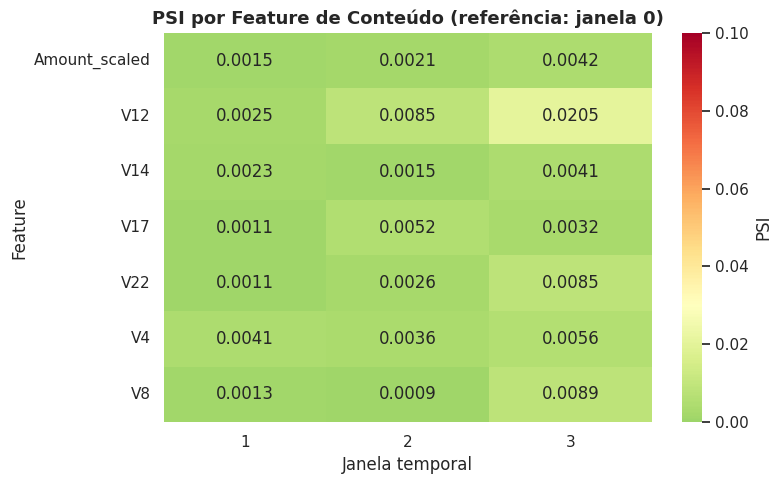

In [ ]:
# ----------------------------------------------------------------
# PSI — Cálculo e Visualização (features de conteúdo)
# ----------------------------------------------------------------
# Hour_sin e Hour_cos foram excluídas: com janelas sequenciais de
# um período curto (7,7h), essas features cíclicas apresentam PSI
# artificialmente alto por cobrirem faixas de hora do dia diferentes
# entre janelas — não representa drift real (ver nota metodológica).

features_monitoradas = ["V4", "V8", "V12", "V22", "V17", "V14", "Amount_scaled"]

resultados_psi = []
for janela_id in sorted(df_janelado["janela"].unique()):
    if janela_id == JANELA_REFERENCIA:
        continue
    df_atual = df_janelado[df_janelado["janela"] == janela_id]

    for feat in features_monitoradas:
        psi = calcular_psi(df_ref[feat].values, df_atual[feat].values)
        resultados_psi.append({"janela": janela_id, "feature": feat, "psi": psi})

df_psi = pd.DataFrame(resultados_psi)
df_psi_pivot = df_psi.pivot(index="feature", columns="janela", values="psi")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_psi_pivot, annot=True, fmt=".4f", cmap="RdYlGn_r",
            vmin=0, vmax=0.10, center=0.03,
            cbar_kws={"label": "PSI"}, ax=ax)
ax.set_title(f"PSI por Feature de Conteúdo (referência: janela {JANELA_REFERENCIA})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Janela temporal")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Análise — PSI: Resultado Final (Features de Conteúdo)

Após excluir as features cíclicas de tempo (ver limitação metodológica
discutida anteriormente), o cálculo de PSI para as features mais
relevantes ao modelo (segundo o SHAP do notebook 06) confirma alta
estabilidade ao longo de todo o período de teste:

- Todas as features permaneceram com PSI abaixo de 0,03 em todas as
  janelas e isso é muito distante do limiar de alerta moderado (0,10).
- **V12 foi a feature com maior variação relativa** (PSI de 0,0205 na
  janela mais distante da referência), mas ainda assim classificada
  como estável segundo os limiares usuais de mercado.
- Nenhuma feature apresentou sinal de drift, nem mesmo moderado.

**Interpretação:** esse resultado é coerente com o curto intervalo de
tempo coberto pelo conjunto de teste (7,7 horas) e não haveria motivo
real para uma mudança relevante de comportamento em um período tão
breve. A ausência de drift aqui não deve ser confundida com garantia de
estabilidade em produção real, onde o monitoramento precisaria cobrir
semanas ou meses para capturar mudanças genuínas de comportamento de
fraudadores e clientes legítimos.

In [ ]:
!pip install evidently --quiet

In [ ]:
# ================================================================
# EVIDENTLY AI — Relatório de Drift (Features + Score do Modelo)
# ================================================================
# Substitui a implementação manual de CSI por uma biblioteca
# especializada e testada, evitando as armadilhas estatísticas
# identificadas no cálculo manual anterior (normalização inválida
# de médias de score como se fossem distribuições de frequência)

# ----------------------------------------------------------------
# EVIDENTLY AI — Loop completo por janela, com extração estruturada
# ----------------------------------------------------------------

from evidently import Report
from evidently.presets import DataDriftPreset

# ----------------------------------------------------------------
# EVIDENTLY AI (API atual, v0.7.21) — Teste com uma janela
# ----------------------------------------------------------------

from evidently import Report
from evidently.presets import DataDriftPreset

colunas_para_drift = features_monitoradas + ["score_lgbm"]

df_referencia = df_janelado[df_janelado["janela"] == JANELA_REFERENCIA][colunas_para_drift].copy()
df_atual_teste = df_janelado[df_janelado["janela"] == 3][colunas_para_drift].copy()  # janela mais distante, teste

# method="psi" alinha com a métrica que já usamos no restante do notebook
report = Report([DataDriftPreset(method="psi")])
my_eval = report.run(current_data=df_atual_teste, reference_data=df_referencia)

# Exibe o relatório interativo direto no notebook
my_eval


def extrair_psi_evidently(resultado_dict):
    """Extrai PSI por coluna a partir do dict retornado pelo Evidently 0.7.x."""
    registros = []
    for metrica in resultado_dict["metrics"]:
        config = metrica.get("config", {})
        if config.get("type") == "evidently:metric_v2:ValueDrift":
            registros.append({
                "feature": config["column"],
                "psi": metrica["value"]
            })
    return pd.DataFrame(registros)

resultados_evidently = []

for janela_id in sorted(df_janelado["janela"].unique()):
    if janela_id == JANELA_REFERENCIA:
        continue

    df_atual = df_janelado[df_janelado["janela"] == janela_id][colunas_para_drift].copy()

    report = Report([DataDriftPreset(method="psi")])
    my_eval = report.run(current_data=df_atual, reference_data=df_referencia)

    df_psi_janela = extrair_psi_evidently(my_eval.dict())
    df_psi_janela["janela"] = janela_id
    resultados_evidently.append(df_psi_janela)

    print(f"Janela {janela_id} processada ({len(df_atual):,} transações).")

df_psi_evidently = pd.concat(resultados_evidently, ignore_index=True)
df_psi_evidently_pivot = df_psi_evidently.pivot(index="feature", columns="janela", values="psi")

print("\nPSI por feature e janela (Evidently AI):\n")
print(df_psi_evidently_pivot.round(4).to_string())

Janela 1 processada (15,248 transações).
Janela 2 processada (14,929 transações).
Janela 3 processada (10,540 transações).

PSI por feature e janela (Evidently AI):

janela              1       2       3
feature                              
Amount_scaled  0.0088  0.0098  0.0085
V12            0.0059  0.0228  0.0297
V14            0.0069  0.0047  0.0044
V17            0.0054  0.0117  0.0087
V22            0.0072  0.0147  0.0205
V4             0.0063  0.0051  0.0209
V8             0.0019  0.0055  0.0096
score_lgbm     0.0081  0.0107  0.0073


## Análise — CSI (Features) e PSI (Score do Modelo) via Evidently AI

Utilizamos a biblioteca Evidently AI (v0.7.21) para calcular a
estabilidade das features mais relevantes ao modelo que é o **CSI**
(Characteristic Stability Index) e, adicionalmente, do próprio score
de saída do LightGBM (`score_lgbm`) o **PSI** (Population Stability
Index) propriamente dito, também referido como "drift de score". Ambas
as métricas usam a mesma fórmula matemática, aplicada a objetos
diferentes: as variáveis de entrada, no caso do CSI, e a saída do
modelo, no caso do PSI. O cálculo foi feito com validação estatística
testada pela biblioteca, em vez de uma implementação manual, que se
mostrou metodologicamente frágil em uma tentativa anterior.

**Resultado (referência: janela 0):**

| Feature | Janela 1 | Janela 2 | Janela 3 |
|---|---|---|---|
| Amount_scaled (CSI) | 0,0088 | 0,0098 | 0,0085 |
| V12 (CSI) | 0,0059 | 0,0228 | 0,0297 |
| V14 (CSI) | 0,0069 | 0,0047 | 0,0044 |
| V17 (CSI) | 0,0054 | 0,0117 | 0,0087 |
| V22 (CSI) | 0,0072 | 0,0147 | 0,0205 |
| V4 (CSI) | 0,0063 | 0,0051 | 0,0209 |
| V8 (CSI) | 0,0019 | 0,0055 | 0,0096 |
| **score_lgbm (PSI)** | 0,0081 | 0,0107 | 0,0073 |

**Todos os valores permanecem muito abaixo do limiar de alerta (0,10)**,
tanto para o CSI das features individuais quanto para o PSI do score de
saída do modelo. Os resultados de CSI são consistentes com o cálculo
manual realizado anteriormente neste notebook, servindo como validação
cruzada entre as duas abordagens.

**Conclusão:** dentro do período de teste disponível (7,7 horas), não há
evidência de drift relevante, nem no CSI das features de entrada mais
importantes para o modelo, nem no PSI da distribuição do score de saída.
Esse resultado é esperado dado o curto intervalo de tempo total
analisado; um monitoramento real em produção precisaria cobrir um
período significativamente mais longo (semanas ou meses) para capturar
mudanças genuínas de comportamento de fraudadores e clientes legítimos.

# **Conclusão — Simulação de Drift e Monitoramento**

Este notebook simulou o monitoramento contínuo de um sistema de detecção
de fraude em produção, dividindo o conjunto de teste em janelas
temporais sucessivas e avaliando a estabilidade das características de
entrada (CSI) e do score de saída do modelo (PSI), com apoio da
biblioteca Evidently AI.

**1. Definição das janelas temporais**

O conjunto de teste (7,7 horas, 56.744 transações, 74 fraudes) foi
dividido em 4 janelas sequenciais. A divisão em 8 janelas foi descartada
por gerar uma janela com apenas 2 fraudes  o que é um volume estatisticamente
frágil demais para uma análise confiável. A divisão em 4 janelas ofereceu
o melhor equilíbrio entre granularidade temporal e robustez estatística,
com a janela 0 servindo como referência (baseline) para as comparações
seguintes.

**2. CSI das features de entrada — estável**

Todas as features mais relevantes ao modelo (V4, V8, V12, V17, V22, V14,
Amount_scaled) apresentaram CSI abaixo de 0,03 em todas as janelas
comparadas o que é muito distante do limiar de alerta (0,10). V12 e V4
mostraram a maior variação relativa, mas ainda dentro da faixa
considerada estável.

**3. PSI do score do modelo — estável**

O score de saída do LightGBM (`score_lgbm`) também permaneceu estável ao
longo de todo o período (PSI entre 0,0073 e 0,0107), indicando que o
comportamento do modelo, como um todo, não se deslocou de forma
perceptível dentro do intervalo de tempo analisado.

**4. Limitação metodológica identificada e corrigida ao longo do processo**

Uma primeira tentativa de calcular o CSI manualmente (via score médio
por decil de feature) revelou-se estatisticamente inválida, a
normalização de médias de score como se fossem distribuições de
frequência gerou valores de CSI superiores a 1 (matematicamente
implausíveis para essa métrica). A correção adotou a biblioteca
Evidently AI, com validação estatística testada, e os resultados de CSI
para as features de conteúdo foram consistentes entre o cálculo manual
de PSI e a biblioteca especializada.

**5. Limitação de features cíclicas de tempo**

`Hour_sin` e `Hour_cos` foram excluídas da análise de CSI, já que janelas
sequenciais de um período curto (7,7h) cobrem naturalmente faixas de
hora do dia diferentes entre si gerando CSI artificialmente alto sem
relação com drift real de comportamento.

**6. Conclusão sobre drift no período analisado**

Não há evidência de drift relevante, nem no CSI das features de
entrada, nem no PSI do score do modelo dentro das 7,7 horas cobertas
pelo conjunto de teste. Esse resultado é esperado e não deve ser
interpretado como garantia de estabilidade em produção real: um período
tão curto não oferece condições para que mudanças genuínas de
comportamento de fraudadores ou clientes legítimos se manifestem.

## Limitações gerais deste notebook

- O dataset cobre apenas ~48 horas no total, período curto demais para
  capturar drift real e esta análise demonstra a metodologia correta de
  monitoramento, não evidência definitiva de estabilidade em produção.
- CSI e PSI de features cíclicas de tempo exigem um desenho experimental
  diferente (comparação de mesma fase de ciclo entre períodos distintos),
  não coberto neste notebook.
- Um pipeline de monitoramento real precisaria rodar continuamente, com
  alertas automatizados e janelas de referência atualizadas
  periodicamente e este notebook demonstra o cálculo pontual, não a
  infraestrutura de monitoramento contínuo em si.